Riley19: ST+PST: Median: 0.1533+0.0106-0.0135
Vinciguerra23: ST+PDT: Median: 0.1773+0.0056-0.0073
Vinciguerra23: ST+PST: Median: 0.188+0.0057-0.0066
Vinciguerra23: PDT-U: Median: 0.1791+0.0113-0.0216
Vinciguerra23: ST-U: Median: 0.1861+0.007-0.0099
Miller19: 2 spots: Median: 0.1603+0.0086-0.0084
Miller19: 3 spots: Median: 0.1631+0.0082-0.0087


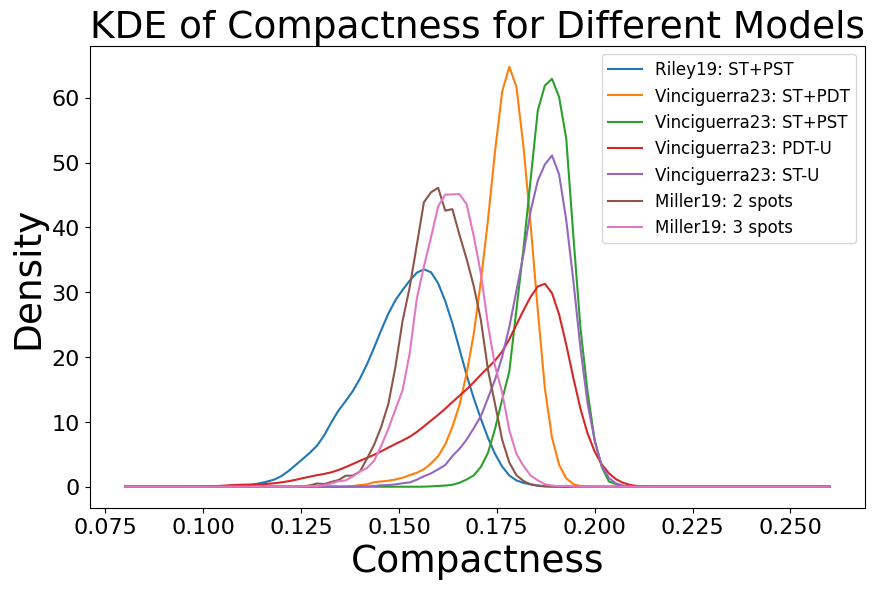

In [1]:
# Importing packages and loading data
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

data_files = [
      ('Riley19: ST+PST', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/ST_PST19'),
    ('Vinciguerra23: ST+PDT', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/ST_PDT'), 
    ('Vinciguerra23: ST+PST', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/ST_PST'),
    ('Vinciguerra23: PDT-U', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/PDT_U'),
    ('Vinciguerra23: ST-U', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/ST_U'),
    ('Miller19: 2 spots', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/2spot'),
    ('Miller19: 3 spots', '/Users/ryanoconnor/Desktop/NeutronStarStuff/datafiles/3spot')
]

# Define constants 
G = 6.67430e-11 # m^3 kg^-1 s^-2
c = 2.99792458e8 # m s^-1
# Calculate compactness and KDEs
compactness = {}
KDEs = {}
C_med = {}
for name, filename in data_files:
    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]
    M = M * 1.98847e30 # Convert solar masses to kg
    R = R * 1e3       # Convert km to m
    values = np.vstack([R, M])  # shape (2, N)
    compactness[name] = G * M / (R*c**2) # dimensionless
    C_med[name] = np.median(compactness[name])
    KDEs[name] = gaussian_kde(compactness[name], bw_method='silverman')
    print(f"{name}: Median: {round(np.median(compactness[name]), 4)}+{round(np.percentile(compactness[name], 84)-np.median(compactness[name]), 4)}-{round(np.median(compactness[name])-np.percentile(compactness[name], 16), 4)}")

# Set up grid
C_grid = np.linspace(0.08, 0.26, 100)

# Evaluate KDE on grid and normalize
KDE_grid_values = {}
for name in KDEs:
    KDE_grid_values[name] = KDEs[name].evaluate(C_grid)
    KDE_grid_values[name] /= np.trapz(KDE_grid_values[name], C_grid)

# Plot the results
plt.figure(figsize=(10, 6))
for name in KDEs:
    plt.plot(C_grid, KDE_grid_values[name], label=name)
plt.xlabel('Compactness', fontsize=27)
plt.xticks(fontsize=16)
plt.ylabel('Density', fontsize=27)
plt.yticks(fontsize=16)
plt.title('KDE of Compactness for Different Models', fontsize=27)
plt.legend(fontsize=12)

#Save plot 
plt.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDECompactnessVariousModels.png', dpi=300)


<>:43: SyntaxWarning: invalid escape sequence '\%'
<>:45: SyntaxWarning: invalid escape sequence '\%'
<>:43: SyntaxWarning: invalid escape sequence '\%'
<>:45: SyntaxWarning: invalid escape sequence '\%'
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_62972/2277821678.py:43: SyntaxWarning: invalid escape sequence '\%'
  plt.axvline(val, linestyle='-.', color='black', linewidth=1.5, label=f"{int(q*100)}\%: {val:.3f}")
/var/folders/8y/nj5lgzs160d7d9cjllp7s7sm0000gn/T/ipykernel_62972/2277821678.py:45: SyntaxWarning: invalid escape sequence '\%'
  plt.axvline(val, linestyle='--', color='black', linewidth=0.75, label=f"{int(q*100)}\%: {val:.3f}")


16%: 0.16595416044252267
50%: 0.17142193299361097
84%: 0.17611216085570466


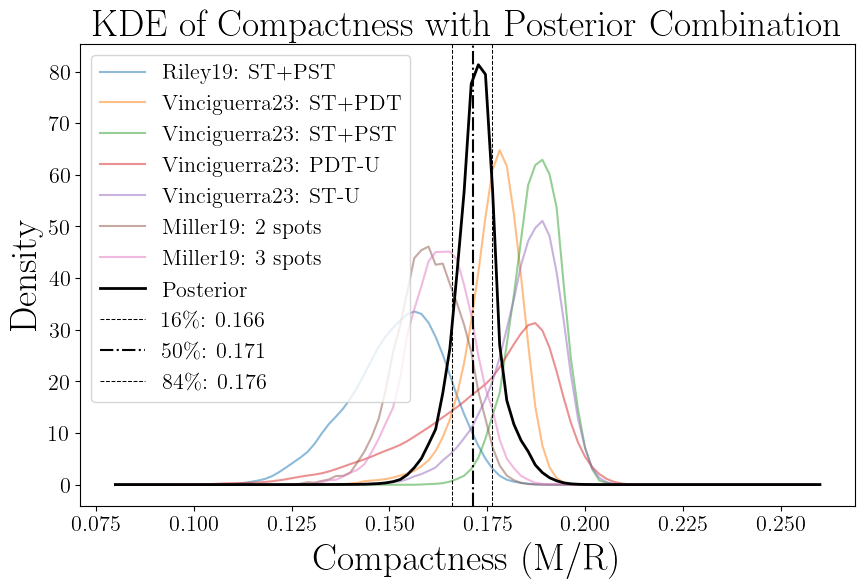

<Figure size 640x480 with 0 Axes>

In [6]:
# Plot definitions
fontsize = 27
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# Define Uniform Prior and "Bad" Distributions (Broad Gaussians at the same mean)
p_grid = np.linspace(0,1,100)

S = 0.075

def f_bad(C):
    """Broad Gaussian likelihood representing a 'bad' measurement."""
    return norm.pdf(C, loc=(np.mean(C)), scale=S)

# Posterior Combination
posterior = np.zeros_like(C_grid)
for i, compactness in enumerate(C_grid):
    L_p = np.ones_like(p_grid)
    for name in KDEs:
        f_good_val = KDEs[name].evaluate(compactness)
        f_bad_val = f_bad(compactness)
        L_p *= (p_grid * f_good_val + (1 - p_grid) * f_bad_val)
    
    # Integrate over p (uniform prior)
    posterior[i] = np.trapz(L_p, p_grid)

# Normalize the posterior and compute quantiles
Z = np.trapz(posterior, C_grid) 
posterior /= Z
quantiles = [0.16, 0.5, 0.84]
# Compute quantile values
quantile_values = np.interp(quantiles, np.cumsum(posterior) * (C_grid[1] - C_grid[0]), C_grid)
for q, val in zip(quantiles, quantile_values):
    print(f"{int(q*100)}%: {val}")

# Plot over individual models 
plt.figure(figsize=(10, 6))
for name in KDEs:
    plt.plot(C_grid, KDE_grid_values[name], label=name, alpha=0.5)
plt.plot(C_grid, posterior, label="Posterior", color='black', linewidth=2)
for q, val in zip(quantiles, quantile_values):
    if q == 0.5:
        plt.axvline(val, linestyle='-.', color='black', linewidth=1.5, label=f"{int(q*100)}\%: {val:.3f}")
    else:
        plt.axvline(val, linestyle='--', color='black', linewidth=0.75, label=f"{int(q*100)}\%: {val:.3f}")
plt.xlabel('Compactness (M/R)', fontsize=fontsize)
plt.xticks(fontsize=16)
plt.ylabel('Density', fontsize=fontsize)
plt.yticks(fontsize=16)
plt.title('KDE of Compactness with Posterior Combination', fontsize=fontsize)
plt.legend(fontsize=16)
plt.show()

# Save figure
plt.savefig('/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDECompactnessPosteriorvsIndividual.png', dpi=300)

In [3]:
# Score each individual measurement against the posterior
P_vi_1 = {}
epsilon = 1e-300  # Tiny value to avoid divide-by-zero
for name in KDEs:
    # if name == 'posterior':
    #     continue  # Skip the posterior itself
    prob_grid = np.zeros(C_grid.shape)
    for i in range(C_grid.shape[0]):
        C_val = C_grid[i]
        f_good = KDE_grid_values[name][i]
        f_bad_value = f_bad(C_val)
        p_term = (p_grid * f_good) / (p_grid * f_good + (1 - p_grid) * f_bad_value + epsilon)
        prob_grid[i] = np.trapz(p_term, p_grid) * posterior[i]
    P_vi_1[name] = np.trapz(prob_grid, C_grid)
    print(f"Probability of {name} being good: {P_vi_1[name]:.4f}")

Probability of Riley19: ST+PST being good: 0.5342
Probability of Vinciguerra23: ST+PDT being good: 0.7495
Probability of Vinciguerra23: ST+PST being good: 0.4609
Probability of Vinciguerra23: PDT-U being good: 0.6899
Probability of Vinciguerra23: ST-U being good: 0.6289
Probability of Miller19: 2 spots being good: 0.6439
Probability of Miller19: 3 spots being good: 0.7013
